# Proyecto Final Curso Aprendizaje automátivo 1: Predecir el porcentaje de infestación de Diatraea

## Estudiantes
- Alfonso Arbelaez
- Ricardo Delgado

## Introducción
El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de predecir las toneladas de caña por hectárea y el porcentaje de sacarosa utilizando el dataset BD_IPSA_1940. 

Este problema corresponde a una tarea de clasificación.



## Exploración inicial de los datos

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [33]:
df = pd.read_excel("../data/raw/BD_IPSA_1940.xlsx")

# Definición de la variable objetivo
tch = "TCH"

df.head()

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


### Descripción de los datos

#### Información del predio

| Columna  | Significado        |
| -------- | -------------------------- |
| **NOME** | Nombre del registro, que puede corresponder al nombre de la finca, campo o unidad de análisis. |
| **FAZ**  | Código o identificador numérico de la hacienda o finca.         |
| **TAL**  | identificador de una subunidad o lote.   |


#### Tipo de tratamiento

| Columna       | Significado                                     |
| ------------- | ----------------------------------------------- |
| **tipocorte** | Tipo de cosecha o manejo (ej: mecanizado verde) |
| **variedad**  | Variedad de caña                                |
| **madurada**  | Si la caña fue madurada o tratada               |
| **producto**  | Producto aplicado (regulador fisiológico)       |

#### Variables del tratamiento

| Columna      | Significado                 |
| ------------ | --------------------------- |
| **dosismad** | Dosis aplicada del producto |
| **semsmad**  | Semanas desde aplicación    |

#### Características del cultivo

| Columna    | Significado                             |
| ---------- | --------------------------------------- |
| **edad**   | Edad del cultivo                        |
| **cortes** | Número de cortes realizados             |
| **me**     | Posiblemente medida de maduración       |
| **vejez**  | Indicador de envejecimiento del cultivo |

#### Variables de calidad

| Columna      | Significado                       |
| ------------ | --------------------------------- |
| **sacarosa** | Porcentaje de sacarosa en la caña |

#### Variables temporales

| Columna     | Significado            |
| ----------- | ---------------------- |
| **mes**     | Mes                    |
| **periodo** | Año + mes (AAAAMM) |

#### Variables de producción

| Columna | Significado                    |
| ------- | ------------------------------ |
| **TCH** | Toneladas de caña por hectárea |

#### Variables climáticas

| Columna     | Significado   |
| ----------- | ------------- |
| **lluvias** | Precipitación |


#### Variables de agrupación

| Columna            | Significado                 |
| ------------------ | --------------------------- |
| **grupo_tenencia** | Grupo de propiedad o manejo |


#### Variable sobre plagas

| Columna         | Significado                                                       |
| --------------- | ----------------------------------------------------------------- |
| **pct_diatrea** | Porcentaje de infestación de **Diatraea (barrenador de la caña)** |

#### Variables objetivos

| Columna     | Significado            |
| ----------- | ---------------------- |
| **TCH**     | Toneladas de caña por hectárea.                    |
| **%Sacarosa** | Porcentaje o cantidad de sacarosa (azúcar) presente en el producto, fundamental en cultivos azucareros.  |



In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2187 non-null   int64  
 1   NOME            2187 non-null   str    
 2   FAZ             2187 non-null   int64  
 3   TAL             2187 non-null   object 
 4   tipocorte       2187 non-null   str    
 5   variedad        2187 non-null   str    
 6   madurada        2187 non-null   str    
 7   producto        2187 non-null   str    
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187 non-null   float64
 15  mes             2187 non-null   int64  
 16  periodo         2187 non-null   int64  
 17  TCH             2187 non-null   int64  
 18 

In [35]:
df.describe()

,Unnamed: 0,FAZ,dosismad,semsmad,edad,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
count,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000
mean,2126.506630,80588.332876,0.993278,9.164838,12.766118,2.794239,9.197759,4.172154,12.777732,6.758573,201887.691358,142.393233,118.051212,2.435299,4.317284
std,1228.561661,572.818299,0.309096,3.441579,1.117866,1.621195,1.574409,6.339255,0.854397,3.482444,131.982686,25.838029,144.424675,0.704058,2.591956
min,11.000000,80100.000000,0.000000,-1.600000,10.300000,1.000000,3.400000,0.200000,9.200000,1.000000,201407.000000,6.000000,0.000000,1.000000,0.200000
25%,1038.000000,80222.000000,0.800000,7.100000,12.000000,1.000000,8.200000,2.100000,12.200000,4.000000,201807.000000,126.000000,0.000000,2.000000,2.900000
50%,2219.000000,80396.000000,1.000000,8.700000,12.500000,2.000000,9.100000,2.600000,12.800000,7.000000,201908.000000,144.000000,77.000000,3.000000,3.700000
75%,3223.500000,80660.000000,1.200000,10.600000,13.300000,4.000000,10.100000,3.300000,13.300000,10.000000,202005.000000,159.000000,171.500000,3.000000,5.000000
max,4222.000000,82519.000000,9.000000,45.000000,21.100000,14.000000,15.000000,102.900000,16.000000,12.000000,202101.000000,249.000000,1468.000000,3.000000,25.500000


In [36]:
df.isnull().sum()

Unnamed: 0        0
NOME              0
FAZ               0
TAL               0
tipocorte         0
variedad          0
madurada          0
producto          0
dosismad          0
semsmad           0
edad              0
cortes            0
me                0
vejez             0
sacarosa          0
mes               0
periodo           0
TCH               0
lluvias           0
grupo_tenencia    0
pct_diatrea       0
dtype: int64

#### Distribución de la variable objetivo

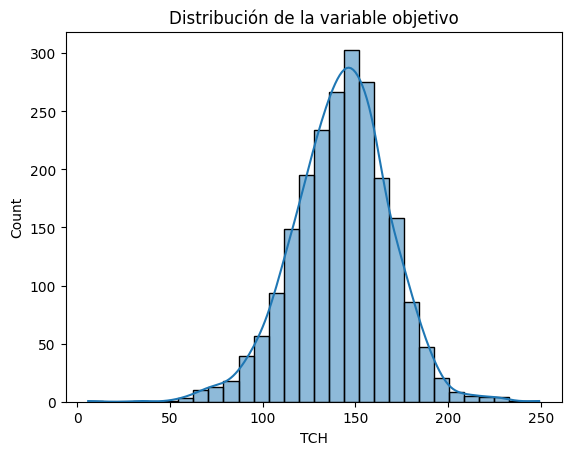

In [37]:

sns.histplot(df[tch], bins=30, kde=True)
plt.title("Distribución de la variable objetivo")
plt.show()

#### Correlaciones

/var/folders/wx/bff99h7511n4zg9r7854hftr0000gn/T/ipykernel_96791/347734384.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include="object").columns


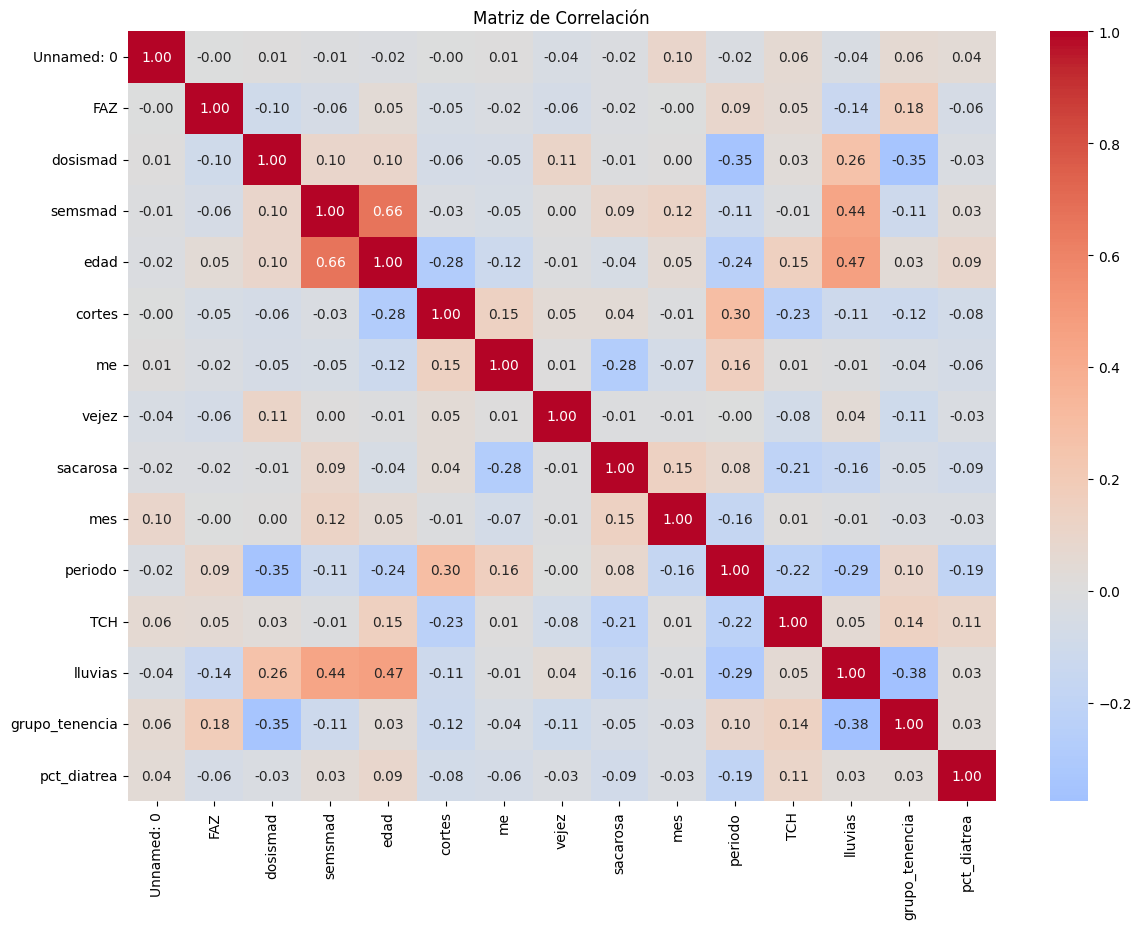

In [40]:
categorical = df.select_dtypes(include="object").columns
numerical = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(14,10))
sns.heatmap(
    df[numerical].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Matriz de Correlación")
plt.show()



Se analizó la matriz de correlación para identificar relaciones fuertes entre variables numéricas y posibles problemas de multicolinealidad

In [39]:
corr[tch].sort_values(ascending=False)

TCH               1.000000
edad              0.150832
grupo_tenencia    0.139681
pct_diatrea       0.105009
Unnamed: 0        0.061601
FAZ               0.051422
lluvias           0.050599
dosismad          0.028478
mes               0.013679
me                0.007890
semsmad          -0.012170
vejez            -0.082230
sacarosa         -0.207086
periodo          -0.221568
cortes           -0.230539
Name: TCH, dtype: float64